# Aproximación interactiva de funciones con redes neuronales

**Aprendizaje Profundo - UNSAM**

## Cómo trabajar este notebook

La idea es repetir siempre la misma secuencia:

1. **Leer** la intuición matemática de la celda.
2. **Predecir** qué debería hacer la red antes de entrenarla.
3. **Ejecutar** el código.
4. **Observar** cómo la curva aprendida cambia con la arquitectura.

En este notebook vas a estudiar cómo una red neuronal construye una función escalonada a partir de piezas lineales, cómo influye la profundidad y qué cambia cuando reemplazamos `ReLU` por activaciones suaves como `tanh`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output
from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False

COLORS = {
    "blue": "#4C72B0",
    "orange": "#DD8452",
    "red": "#C44E52",
    "green": "#55A868",
    "purple": "#8172B2",
    "cyan": "#64B5CD",
    "gray": "#8C8C8C",
}

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

PyTorch: 2.10.0+cu128
NumPy: 2.2.6
Pandas: 2.3.3


## 1. Marco teórico: Teorema de Aproximación Universal

El resultado clásico de **Cybenko (1989)** dice, en términos simples, que una red neuronal con **una sola capa oculta** puede aproximar funciones continuas con la precisión que queramos, siempre que tenga suficientes neuronas.

De forma más formal, si $f: K \subset \mathbb{R}^n \to \mathbb{R}$ es continua y $K$ es compacto, entonces para todo $\varepsilon > 0$ existe un número finito de neuronas $m$ y parámetros tales que

$$

\sup_{x \in K} \left| f(x) - \sum_{j=1}^{m} \alpha_j\, \sigma(w_j^\top x + b_j) \right| < \varepsilon.

$$

La lectura intuitiva es poderosa: **una sola capa oculta ya tiene capacidad universal de representación**. La práctica, sin embargo, nos recuerda tres cosas importantes:

- El teorema garantiza **existencia**, no facilidad de entrenamiento.

- El resultado habla de **funciones continuas sobre conjuntos compactos**.

- Nuestro objetivo de hoy es una **función escalonada**, que tiene discontinuidades en los saltos. Por eso el teorema no aplica literalmente a una función con saltos sobre toda la recta.

La intuición igual sigue siendo muy útil: lo que vamos a estudiar acá es una **aproximación muy ajustada en un intervalo finito y sobre muestras discretas**. En ese sentido, la red puede acercarse mucho a los saltos, aunque no "copie" una discontinuidad ideal de forma literal en el sentido del teorema.

**Antes de ejecutar las próximas celdas, predecí esto:** ¿cuántas "esquinas" o cambios de pendiente necesitás para imitar una función con dos saltos bruscos?

In [ ]:
# Datos sintéticos: una función escalonada con tres niveles
X = torch.arange(-30, 30, 1, dtype=torch.float32).reshape(-1, 1)

def step_target_torch(x):
    """Evalúa el objetivo escalonado sobre tensores de PyTorch."""
    y = torch.zeros_like(x, dtype=torch.float32)
    y[x <= -10] = 1.0
    y[(x > -10) & (x < 10)] = 0.5
    y[x >= 10] = 0.0
    return y

def step_target_numpy(x):

    """Evalúa el objetivo escalonado sobre arreglos de NumPy."""
    x_array = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x_array, dtype=np.float32)
    y[x_array <= -10] = 1.0
    y[(x_array > -10) & (x_array < 10)] = 0.5
    y[x_array >= 10] = 0.0
    return y

Y = step_target_torch(X).reshape(-1, 1)

print(f"Forma de X: {tuple(X.shape)}")
print(f"Forma de Y: {tuple(Y.shape)}")
print(f"Rango de X: [{X.min().item():.1f}, {X.max().item():.1f}]")
print(f"Valores únicos de Y: {torch.unique(Y).tolist()}")

Forma de X: (60, 1)
Forma de Y: (60, 1)
Rango de X: [-30.0, 29.0]
Valores únicos de Y: [0.0, 0.5, 1.0]


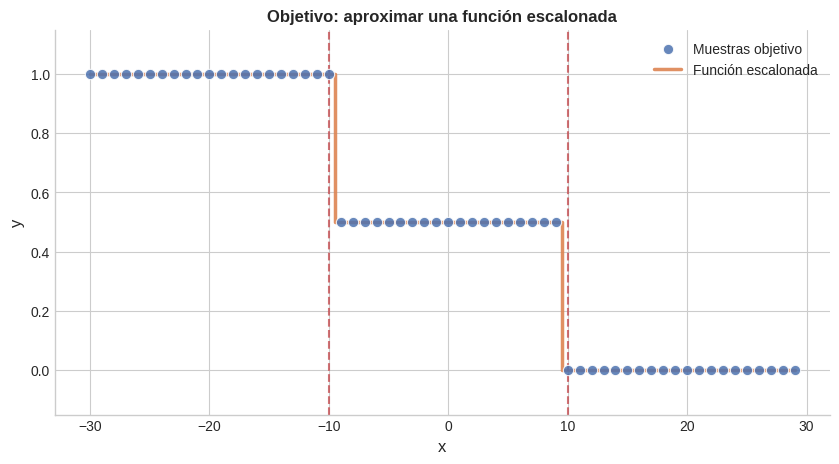

In [3]:
# Visualización de la función objetivo
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    X.numpy().ravel(),
    Y.numpy().ravel(),
    s=55,
    alpha=0.85,
    color=COLORS["blue"],
    edgecolors="white",
    linewidth=0.8,
    label="Muestras objetivo",
    zorder=3,
 )
ax.step(
    X.numpy().ravel(),
    Y.numpy().ravel(),
    where="mid",
    color=COLORS["orange"],
    linewidth=2.5,
    alpha=0.9,
    label="Función escalonada",
    zorder=2,
 )
ax.axvline(-10, color=COLORS["red"], linestyle="--", linewidth=1.5, alpha=0.8)
ax.axvline(10, color=COLORS["red"], linestyle="--", linewidth=1.5, alpha=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Objetivo: aproximar una función escalonada")
ax.set_ylim(-0.15, 1.15)
ax.legend()
plt.show()

## 2. Red neuronal con 1 capa oculta

Vamos a empezar con el caso más importante conceptualmente: una red con **una sola capa oculta**. Según el teorema anterior, esta arquitectura ya debería ser suficiente para aproximar funciones muy complejas si le damos suficientes neuronas.

**Predicción antes de ejecutar:** si la red usa pocas neuronas, ¿esperás una curva demasiado rígida o una curva capaz de doblarse exactamente donde están los saltos?

In [4]:
class OneLayerNet(nn.Module):
    """Red neuronal con una capa oculta y activación ReLU."""

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = self.output(x)
        return x

hidden_neurons = 12
model_1layer = OneLayerNet(input_size=1, hidden_size=hidden_neurons, output_size=1)

print(model_1layer)
print(f"Parámetros totales: {sum(p.numel() for p in model_1layer.parameters())}")

OneLayerNet(
  (hidden): Linear(in_features=1, out_features=12, bias=True)
  (output): Linear(in_features=12, out_features=1, bias=True)
)
Parámetros totales: 37


### La intuición de `ReLU`: construir escalones sumando y restando rectas

Una neurona `ReLU` implementa la función

$$

\operatorname{ReLU}(z) = \max(0, z).

$$

Si escribimos una salida como

$$

y(x) = a\,\max(0, x-b_1) - c\,\max(0, x-b_2),

$$

entonces activamos una recta a partir de $x=b_1$ y luego restamos otra a partir de $x=b_2$. El resultado ya no es una sola línea: aparece una **meseta** entre dos cambios de pendiente.

Al sumar muchas expresiones de este tipo, la red aprende una función por tramos. En otras palabras, la red está **sumando y restando rectas** para fabricar bordes, escalones y transiciones bruscas. Cada neurona agrega una posible **bisagra**; la capa de salida después combina esas piezas con pesos y un sesgo para producir la curva final.

**Leé esto y predecí:** si querés copiar una función con dos saltos marcados, ¿te conviene tener pocas bisagras o muchas?

In [ ]:
def train_and_visualize(model, X, Y, epochs=1200, lr=0.01, plot_every=100, show_progress=True):
    """Entrena el modelo y muestra cómo la red va doblando su predicción."""
    if epochs <= 0:
        raise ValueError("`epochs` debe ser un entero positivo.")
    if plot_every <= 0:
        raise ValueError("`plot_every` debe ser un entero positivo.")

    X = X.detach().clone().float()
    Y = Y.detach().clone().float()
    model = model.float()

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    x_min = float(X.min().item())
    x_max = float(X.max().item())
    X_plot = torch.linspace(x_min, x_max, 400, dtype=X.dtype).reshape(-1, 1)
    Y_plot = step_target_torch(X_plot).reshape(-1, 1)

    def draw_progress(epoch, current_loss, predictions):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle("La red aprende a doblarse para copiar el escalón", fontsize=15, y=1.02)

        x_np = X.detach().cpu().numpy().ravel()
        y_np = Y.detach().cpu().numpy().ravel()
        x_plot_np = X_plot.detach().cpu().numpy().ravel()
        y_plot_np = Y_plot.detach().cpu().numpy().ravel()
        y_pred_np = predictions.detach().cpu().numpy().ravel()

        ax1.scatter(
            x_np,
            y_np,
            s=48,
            color=COLORS["blue"],
            edgecolors="white",
            linewidth=0.8,
            alpha=0.9,
            label="Datos objetivo",
            zorder=3,
        )
        ax1.step(
            x_plot_np,
            y_plot_np,
            where="mid",
            color=COLORS["gray"],
            linewidth=2.2,
            alpha=0.9,
            label="Escalón objetivo",
            zorder=1,
        )
        ax1.plot(
            x_plot_np,
            y_pred_np,
            color=COLORS["red"],
            linewidth=3,
            label="Predicción de la red",
            zorder=4,
        )

        ax1.fill_between(
            x_plot_np,
            y_pred_np,
            y_plot_np,
            color=COLORS["red"],
            alpha=0.08,
            zorder=2,
        )
        ax1.axvline(-10, color=COLORS["orange"], linestyle="--", linewidth=1.5, alpha=0.9)
        ax1.axvline(10, color=COLORS["orange"], linestyle="--", linewidth=1.5, alpha=0.9)
        ax1.set_title(f"Época {epoch}/{epochs} | pérdida = {current_loss:.5f}")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_ylim(-0.15, 1.15)
        ax1.legend(loc="best")

        ax2.plot(losses, color=COLORS["green"], linewidth=2.5)
        ax2.scatter(len(losses) - 1, losses[-1], color=COLORS["orange"], s=60, zorder=3)
        ax2.set_title("Curva de aprendizaje")
        ax2.set_xlabel("Época")
        ax2.set_ylabel("MSE")
        ax2.set_yscale("log")

        fig.tight_layout()
        plt.show()
        print(f"Época [{epoch}/{epochs}] - pérdida: {current_loss:.6f}")

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, Y)
        if not torch.isfinite(loss):
            raise RuntimeError(
                f"La pérdida dejó de ser finita en la época {epoch}. Probá bajar `lr`."
            )

        loss.backward()
        optimizer.step()

        current_loss = float(loss.detach().cpu().item())
        losses.append(current_loss)

        should_plot = show_progress and (epoch == 1 or epoch % plot_every == 0 or epoch == epochs)
        if should_plot:
            model.eval()
            with torch.no_grad():
                smooth_predictions = model(X_plot)
            draw_progress(epoch, current_loss, smooth_predictions)

    return losses

### Entrenamiento interactivo: mirar cómo la recta se dobla

Al ejecutar la siguiente celda, observá especialmente dos cosas:

1. **Dónde aparecen las bisagras** de la predicción.
2. **Cómo la curva roja se aplana** para formar niveles parecidos al escalón objetivo.

Si la intuición de las `ReLU` es correcta, deberías ver que la red empieza siendo casi lineal y luego aprende a construir una aproximación por tramos.

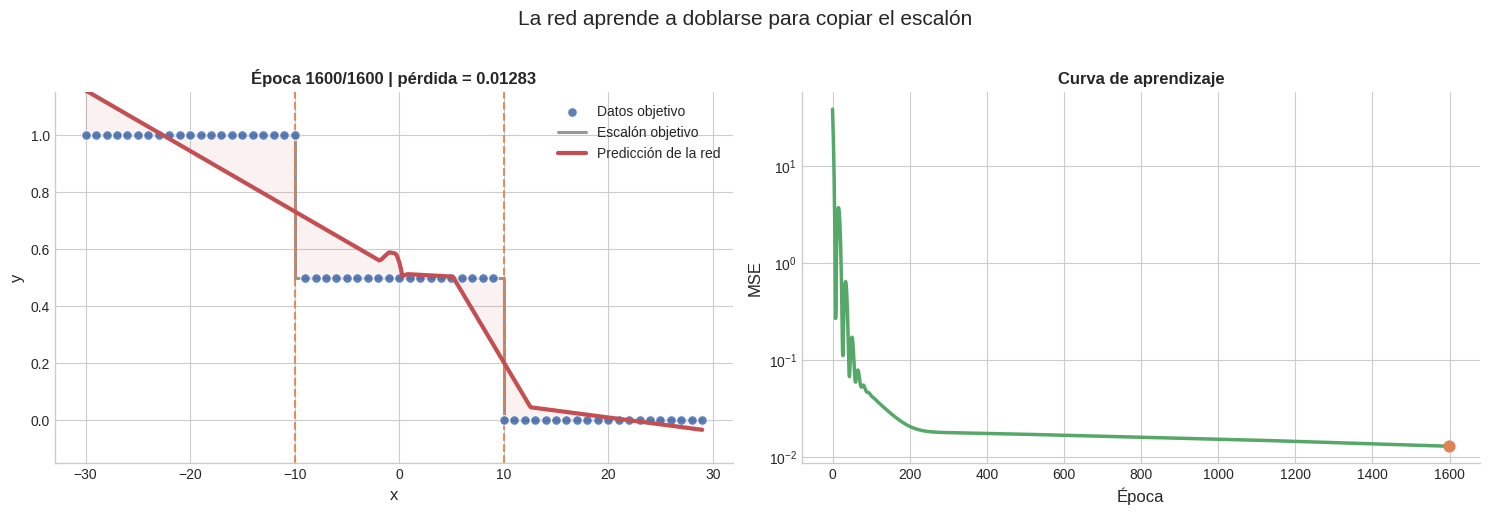

Época [1600/1600] - pérdida: 0.012828


In [6]:
print(f"Entrenando red con 1 capa oculta y {hidden_neurons} neuronas...\n")
losses_1layer = train_and_visualize(
    model_1layer,
    X,
    Y,
    epochs=1600,
    lr=0.01,
    plot_every=200,
 )

### Ver las bisagras: componentes `ReLU` de la capa oculta

La salida final de la red de 1 capa es una suma ponderada de varias neuronas `ReLU`, más un sesgo final. En la próxima celda vamos a graficar esas piezas por separado para ver las **rectas quebradas** que la red combina para construir el escalón.

**Observá dos niveles de representación:**

1. Las activaciones individuales de cada neurona de la capa oculta.

2. La contribución de cada neurona una vez multiplicada por su peso de salida.

La curva final aparece cuando todas esas contribuciones se suman y se agrega el sesgo de salida.

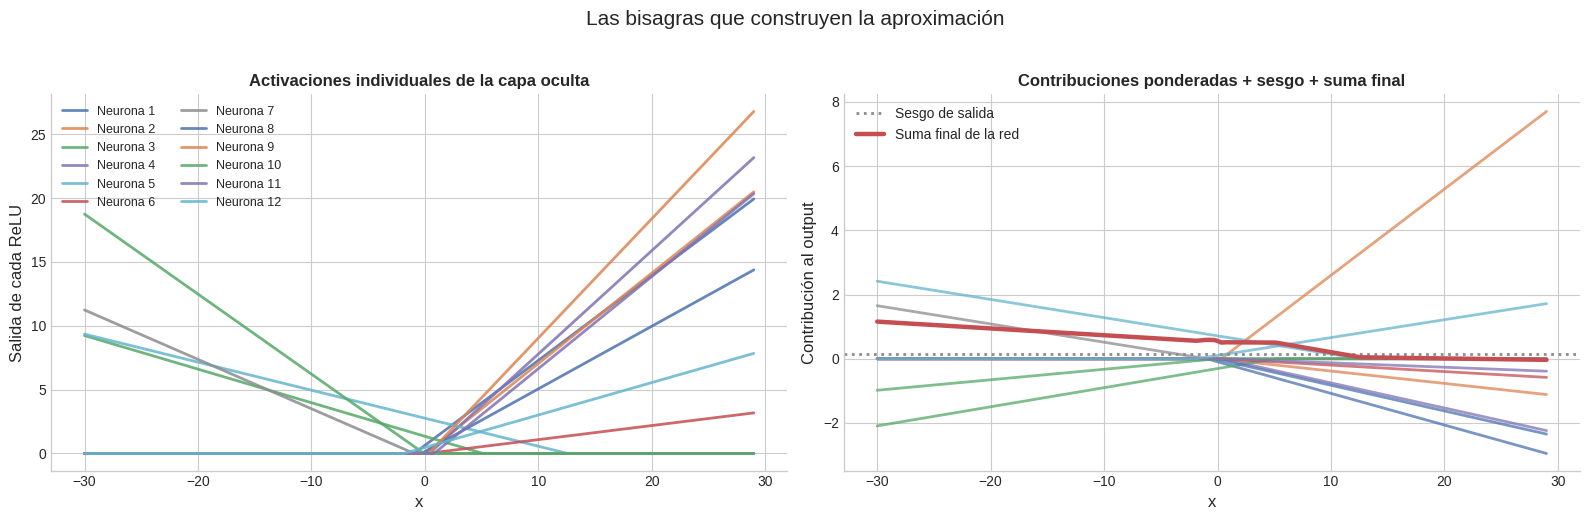

In [ ]:
def plot_relu_components(model, X, n_points=400):

    """Grafica las activaciones ReLU individuales y sus contribuciones ponderadas."""
    if not hasattr(model, "hidden") or not hasattr(model, "output"):
        raise TypeError(
            "`plot_relu_components` requiere un modelo con atributos `hidden` y `output`."
        )

    model.eval()
    X_plot = torch.linspace(
        float(X.min().item()),
        float(X.max().item()),
        n_points,
        dtype=torch.float32,
    ).reshape(-1, 1)

    with torch.no_grad():

        hidden_linear = model.hidden(X_plot)
        hidden_relu = torch.relu(hidden_linear)
        output_weights = model.output.weight.detach().cpu().view(-1)
        output_bias = float(model.output.bias.detach().cpu().view(-1)[0])
        weighted_components = hidden_relu.detach().cpu() * output_weights.view(1, -1)
        final_prediction = model(X_plot).detach().cpu().view(-1)
    x_axis = X_plot.detach().cpu().numpy().ravel()
    hidden_relu_np = hidden_relu.detach().cpu().numpy()
    weighted_components_np = weighted_components.numpy()
    final_prediction_np = final_prediction.numpy()
    palette = [
        COLORS["blue"],
        COLORS["orange"],
        COLORS["green"],
        COLORS["purple"],
        COLORS["cyan"],
        COLORS["red"],
        COLORS["gray"],
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Las bisagras que construyen la aproximación", fontsize=15, y=1.03)

    for idx in range(hidden_relu_np.shape[1]):
        color = palette[idx % len(palette)]
        ax1.plot(
            x_axis,
            hidden_relu_np[:, idx],
            color=color,
            linewidth=2,
            alpha=0.85,
            label=f"Neurona {idx + 1}",
        )
        ax2.plot(
            x_axis,
            weighted_components_np[:, idx],
            color=color,
            linewidth=2,
            alpha=0.75,
        )

    ax1.set_title("Activaciones individuales de la capa oculta")
    ax1.set_xlabel("x")
    ax1.set_ylabel("Salida de cada ReLU")
    ax1.legend(ncol=2, fontsize=9)

    ax2.axhline(output_bias, color=COLORS["gray"], linestyle=":", linewidth=2, label="Sesgo de salida")
    ax2.plot(
        x_axis,
        final_prediction_np,
        color=COLORS["red"],
        linewidth=3.2,
        label="Suma final de la red",
        zorder=4,
    )

    ax2.set_title("Contribuciones ponderadas + sesgo + suma final")
    ax2.set_xlabel("x")
    ax2.set_ylabel("Contribución al output")
    ax2.legend(loc="upper left")

    fig.tight_layout()
    plt.show()

plot_relu_components(model_1layer, X)

### Experimento guiado: cambiar el ancho de la capa oculta

Volvé a la celda donde definimos `hidden_neurons` y probá, por ejemplo:

- `4`: la red tendrá pocas bisagras y tenderá a suavizar demasiado los bordes.
- `8`: ya debería capturar mejor la estructura general.
- `12` o `20`: la curva tendrá más libertad para doblarse cerca de los saltos.

**Pregunta para pensar:** ¿en qué momento agregar neuronas deja de cambiar mucho la calidad visual de la aproximación?

## 3. ¿Ayuda agregar profundidad?

Ahora vamos a comparar con una red de **dos capas ocultas**. La teoría nos dice que una sola capa oculta alcanza, pero una red más profunda puede repartir mejor el trabajo: una capa aprende bisagras intermedias y la siguiente las recombina.

**Predicción antes de ejecutar:** ¿esperás que una red más profunda necesite menos neuronas por capa para aproximar bien los dos bordes del escalón?

In [8]:
class TwoLayerNet(nn.Module):
    """Red neuronal con dos capas ocultas y activación ReLU."""

    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super().__init__()
        self.hidden1 = nn.Linear(input_size, hidden1_size)
        self.hidden2 = nn.Linear(hidden1_size, hidden2_size)
        self.output = nn.Linear(hidden2_size, output_size)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = self.output(x)
        return x

hidden1_neurons = 8
hidden2_neurons = 6
model_2layer = TwoLayerNet(1, hidden1_neurons, hidden2_neurons, 1)

print(model_2layer)
print(f"Parámetros totales: {sum(p.numel() for p in model_2layer.parameters())}")

TwoLayerNet(
  (hidden1): Linear(in_features=1, out_features=8, bias=True)
  (hidden2): Linear(in_features=8, out_features=6, bias=True)
  (output): Linear(in_features=6, out_features=1, bias=True)
)
Parámetros totales: 77


### Entrenamiento de la red profunda

Ejecutá la siguiente celda y compará mentalmente con la red anterior:

- ¿la nueva curva roja se acomoda más rápido?
- ¿los bordes del escalón quedan más nítidos?
- ¿la pérdida final baja mucho o solo un poco?

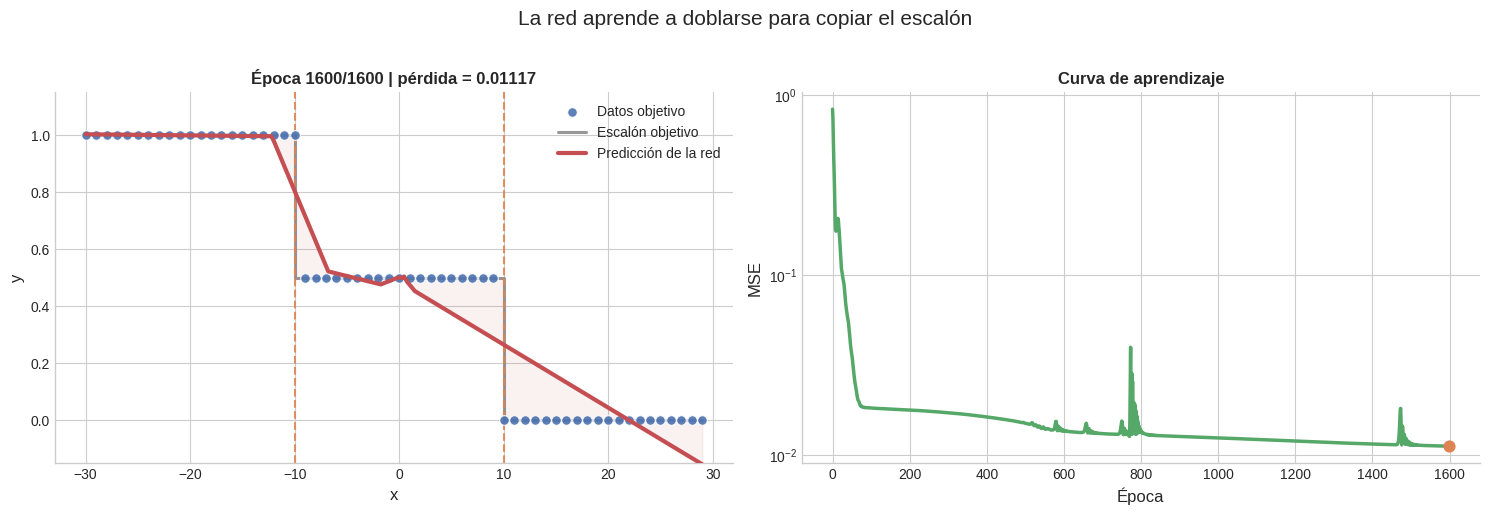

Época [1600/1600] - pérdida: 0.011171


In [9]:
print(
    f"Entrenando red con 2 capas ocultas ({hidden1_neurons}, {hidden2_neurons} neuronas)...\n"
 )
losses_2layer = train_and_visualize(
    model_2layer,
    X,
    Y,
    epochs=1600,
    lr=0.01,
    plot_every=200,
 )

## 4. Comparación sistemática de arquitecturas

Hasta ahora miramos ejemplos individuales. En esta sección vamos a entrenar varias arquitecturas y comparar tres cosas al mismo tiempo:

1. Calidad final de la aproximación.

2. Velocidad de aprendizaje.

3. Número total de parámetros.

> **Nota metodológica:** acá no hacemos separación train/validation/test. Usamos la misma función objetivo para ajuste y visualización porque el foco no es la generalización estadística, sino el **comportamiento de aproximación** sobre una función conocida.

> **Nota de interpretación:** una sola corrida puede depender bastante de la inicialización y de la dinámica de optimización. Para que la comparación sea un poco más estable, en esta sección repetimos cada arquitectura con **3 semillas** y resumimos el comportamiento observado.

In [ ]:
def train_model_silent(model, X, Y, epochs=1600, lr=0.01):

    """Entrena sin gráficos para comparar arquitecturas rápidamente."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    X = X.float()
    Y = Y.float()
    model = model.float()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, Y)
        if not torch.isfinite(loss):
            raise RuntimeError("La pérdida dejó de ser finita durante la comparación.")
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu().item()))
    return losses

configs = [
    {"name": "1 capa - 4 neuronas", "layers": [4]},
    {"name": "1 capa - 8 neuronas", "layers": [8]},
    {"name": "1 capa - 12 neuronas", "layers": [12]},
    {"name": "2 capas - [6, 4]", "layers": [6, 4]},
    {"name": "2 capas - [8, 6]", "layers": [8, 6]},
    {"name": "2 capas - [12, 8]", "layers": [12, 8]},
]

comparison_seeds = [7, 42, 123]

results = {}
X_plot = torch.linspace(float(X.min().item()), float(X.max().item()), 400).reshape(-1, 1)
n_params = 0
print("Entrenando múltiples arquitecturas (3 semillas por arquitectura)...\n")
for config in configs:
    print(f"Entrenando: {config['name']}")
    run_records = []
    for seed in comparison_seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        if len(config["layers"]) == 1:
            model = OneLayerNet(1, config["layers"][0], 1)
        else:
            model = TwoLayerNet(1, config["layers"][0], config["layers"][1], 1)

        n_params = sum(p.numel() for p in model.parameters())
        losses = train_model_silent(model, X, Y, epochs=1600, lr=0.01)
        model.eval()
        with torch.no_grad():
            Y_pred = model(X_plot)

        run_records.append(
            {
                "seed": seed,
                "model": model,
                "losses": np.array(losses, dtype=np.float64),
                "final_loss": float(losses[-1]),
                "best_loss": float(np.min(losses)),
                "prediction": (X_plot.clone(), Y_pred.clone()),
            }
        )

    final_losses = np.array([run["final_loss"] for run in run_records], dtype=np.float64)
    best_losses = np.array([run["best_loss"] for run in run_records], dtype=np.float64)
    loss_matrix = np.vstack([run["losses"] for run in run_records])
    representative_index = np.argsort(final_losses)[len(final_losses) // 2]
    representative_run = run_records[representative_index]

    results[config["name"]] = {
        "params": n_params,
        "runs": run_records,
        "mean_losses": loss_matrix.mean(axis=0),
        "std_losses": loss_matrix.std(axis=0),
        "final_loss_mean": float(final_losses.mean()),
        "final_loss_std": float(final_losses.std()),
        "best_loss_observed": float(best_losses.min()),
        "representative_seed": representative_run["seed"],
        "prediction": representative_run["prediction"],
    }

    print(f"  - Parámetros: {n_params}")
    print(
        f"  - Pérdida final media: {results[config['name']]['final_loss_mean']:.6f} "
        f"± {results[config['name']]['final_loss_std']:.6f}"
    )
    print(
        f"  - Mejor pérdida observada en estas corridas: "
        f"{results[config['name']]['best_loss_observed']:.6f}\n"
    )

print("Comparación completada.")

Entrenando múltiples arquitecturas (3 semillas por arquitectura)...

Entrenando: 1 capa - 4 neuronas
  - Parámetros: 13
  - Pérdida final media: 0.017479 ± 0.002007
  - Mejor pérdida observada en estas corridas: 0.014641

Entrenando: 1 capa - 8 neuronas
  - Parámetros: 25
  - Pérdida final media: 0.014697 ± 0.005880
  - Mejor pérdida observada en estas corridas: 0.006382

Entrenando: 1 capa - 12 neuronas
  - Parámetros: 37
  - Pérdida final media: 0.013803 ± 0.003814
  - Mejor pérdida observada en estas corridas: 0.009697

Entrenando: 2 capas - [6, 4]
  - Parámetros: 45
  - Pérdida final media: 0.008145 ± 0.004128
  - Mejor pérdida observada en estas corridas: 0.001284

Entrenando: 2 capas - [8, 6]
  - Parámetros: 77
  - Pérdida final media: 0.003107 ± 0.001685
  - Mejor pérdida observada en estas corridas: 0.000966

Entrenando: 2 capas - [12, 8]
  - Parámetros: 137
  - Pérdida final media: 0.002451 ± 0.001634
  - Mejor pérdida observada en estas corridas: 0.000676

Comparación complet

### Visualización comparativa

Antes de ejecutar, hacé una última predicción: ¿qué arquitectura creés que va a dibujar mejor los dos bordes del escalón sin usar demasiados parámetros?

En cada panel vamos a mostrar una **corrida representativa** de esa arquitectura. La comparación cuantitativa más estable va a quedar resumida después con promedios y dispersión entre semillas.

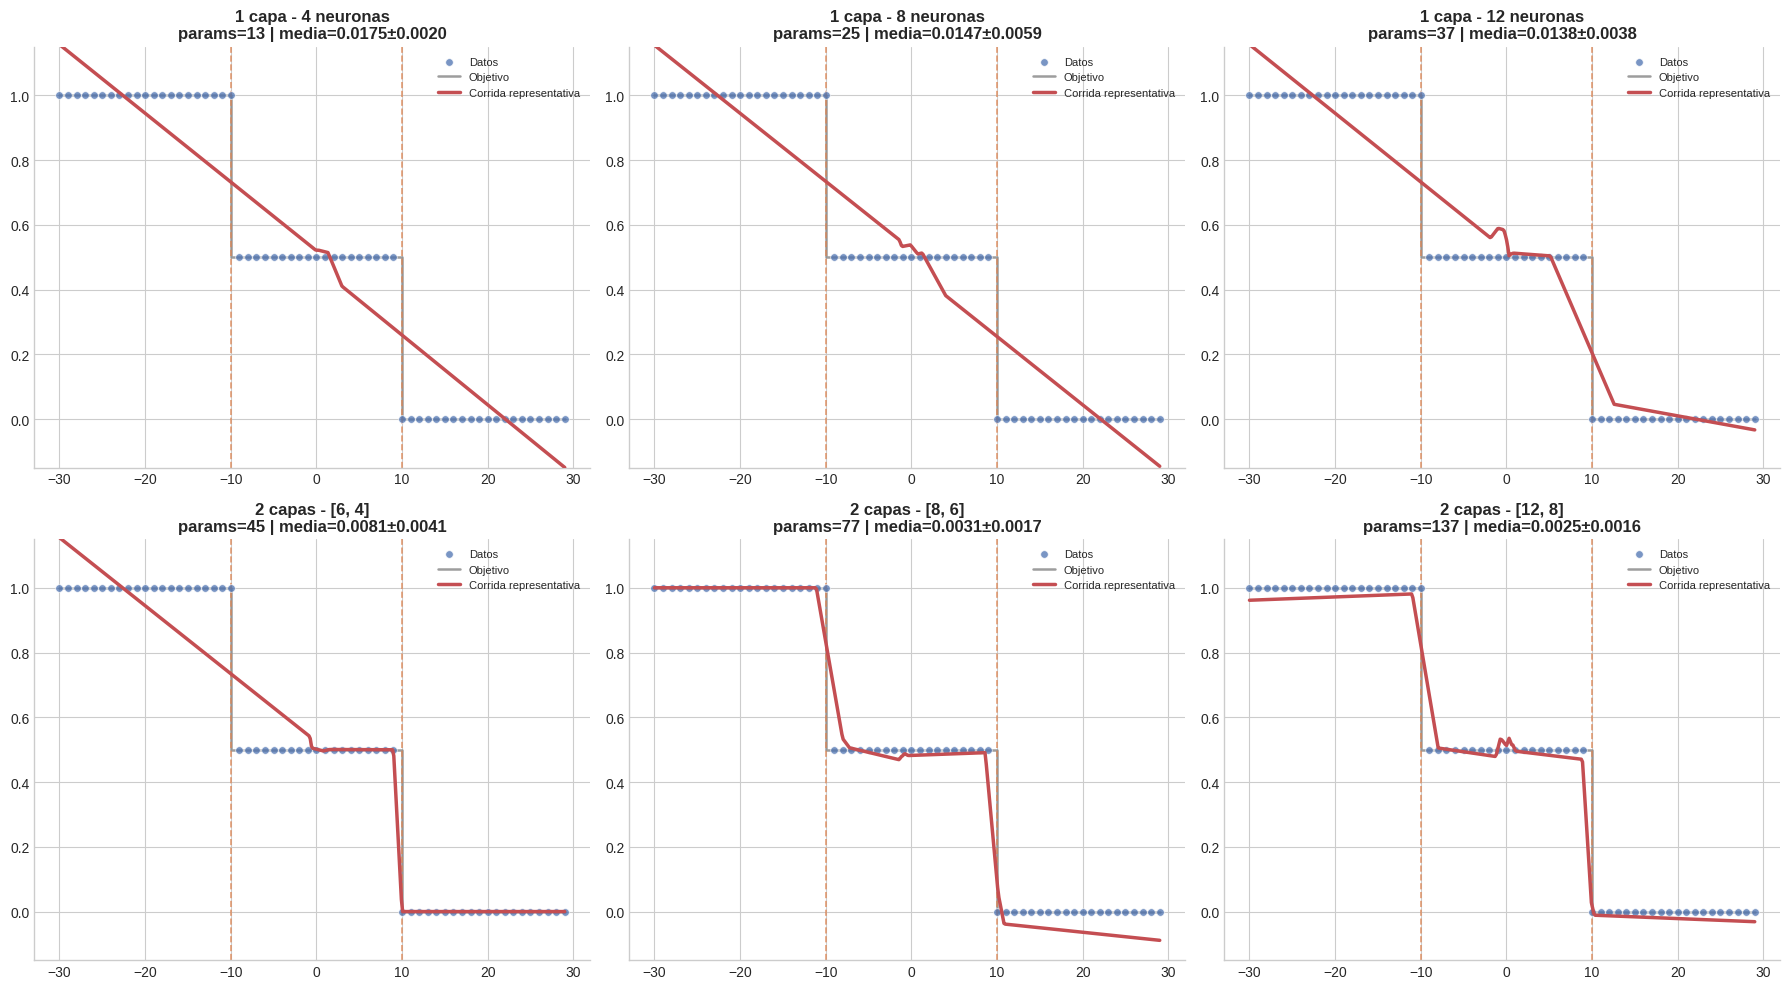

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):

    X_plot_result, Y_pred = result["prediction"]
    x_plot_np = X_plot_result.detach().cpu().numpy().ravel()
    y_pred_np = Y_pred.detach().cpu().numpy().ravel()

    axes[idx].scatter(
        X.detach().cpu().numpy().ravel(),
        Y.detach().cpu().numpy().ravel(),
        s=30,
        alpha=0.75,
        color=COLORS["blue"],
        edgecolors="white",
        linewidth=0.6,
        label="Datos",
        zorder=3,
    )
    axes[idx].step(
        x_plot_np,
        step_target_numpy(x_plot_np),
        where="mid",
        color=COLORS["gray"],
        linewidth=1.8,
        alpha=0.85,
        label="Objetivo",
        zorder=1,
    )

    axes[idx].plot(
        x_plot_np,
        y_pred_np,
        color=COLORS["red"],
        linewidth=2.5,
        label="Corrida representativa",
        zorder=4,
    )

    axes[idx].axvline(-10, color=COLORS["orange"], linestyle="--", linewidth=1.2, alpha=0.8)
    axes[idx].axvline(10, color=COLORS["orange"], linestyle="--", linewidth=1.2, alpha=0.8)
    axes[idx].set_title(
        f"{name}\nparams={result['params']} | media={result['final_loss_mean']:.4f}±{result['final_loss_std']:.4f}"
    )

    axes[idx].set_ylim(-0.15, 1.15)
    axes[idx].legend(loc="upper right", fontsize=8)

plt.tight_layout()

plt.show()

### Curvas de aprendizaje y compromiso eficiencia-ajuste

Ahora mirá no solo el resultado final, sino también el proceso. A la izquierda vamos a resumir la evolución promedio de la pérdida para cada arquitectura; a la derecha, el gráfico muestra el compromiso entre **costo** (número de parámetros) y **calidad de ajuste** (pérdida final media) en **este experimento**.

Cada punto representa una arquitectura resumida sobre 3 semillas. Idealmente queremos modelos ubicados más **abajo** y más **a la izquierda**: baja pérdida con pocos parámetros.

La curva punteada no debe leerse como una ley universal, sino como una **frontera observada en estas corridas**. Sirve para orientar la discusión en clase, no para reemplazar un análisis más repetido.

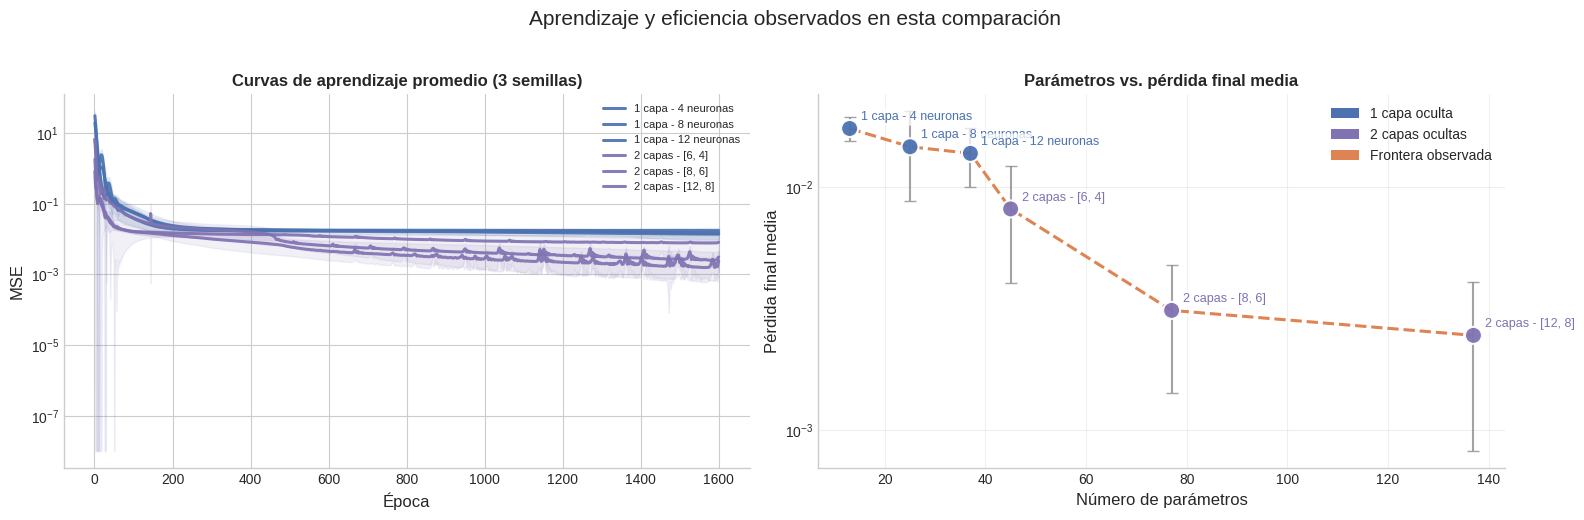

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle("Aprendizaje y eficiencia observados en esta comparación", fontsize=15, y=1.03)

for name, result in results.items():

    color = COLORS["blue"] if "1 capa" in name else COLORS["purple"]
    mean_losses = result["mean_losses"]
    std_losses = result["std_losses"]
    epochs_axis = np.arange(1, len(mean_losses) + 1)
    axes[0].plot(
        epochs_axis,
        mean_losses,
        label=name,
        linewidth=2.2,
        alpha=0.92,
        color=color,
    )
    axes[0].fill_between(
        epochs_axis,
        np.maximum(mean_losses - std_losses, 1e-8),
        mean_losses + std_losses,
        color=color,
        alpha=0.10,
    )

axes[0].set_title("Curvas de aprendizaje promedio (3 semillas)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

names = list(results.keys())
params = np.array([results[name]["params"] for name in names])
final_losses = np.array([results[name]["final_loss_mean"] for name in names])
final_loss_std = np.array([results[name]["final_loss_std"] for name in names])
point_colors = [COLORS["blue"] if "1 capa" in name else COLORS["purple"] for name in names]

axes[1].errorbar(
    params,
    final_losses,
    yerr=final_loss_std,
    fmt="none",
    ecolor=COLORS["gray"],
    elinewidth=1.5,
    capsize=4,
    alpha=0.8,
    zorder=2,
)

axes[1].scatter(

    params,
    final_losses,
    s=150,
    c=point_colors,
    edgecolors="white",
    linewidth=1.5,
    alpha=0.95,
    zorder=3,
 )

for name, x_param, y_loss, color in zip(names, params, final_losses, point_colors):

    axes[1].annotate(
        name,
        xy=(x_param, y_loss),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=9,
        color=color,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

pareto_points = []

best_loss_so_far = np.inf

for x_param, y_loss, name in sorted(zip(params, final_losses, names), key=lambda item: item[0]):

    if y_loss < best_loss_so_far:
        pareto_points.append((x_param, y_loss, name))
        best_loss_so_far = y_loss

if len(pareto_points) >= 2:

    axes[1].plot(
        [point[0] for point in pareto_points],
        [point[1] for point in pareto_points],
        color=COLORS["orange"],
        linestyle="--",
        linewidth=2.2,
        label="Frontera observada",
        zorder=2,
    )

axes[1].set_title("Parámetros vs. pérdida final media")
axes[1].set_xlabel("Número de parámetros")
axes[1].set_ylabel("Pérdida final media")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
axes[1].legend(

    handles=[
        Patch(facecolor=COLORS["blue"], label="1 capa oculta"),
        Patch(facecolor=COLORS["purple"], label="2 capas ocultas"),
        Patch(facecolor=COLORS["orange"], label="Frontera observada"),
    ],
    loc="best",

 )

fig.tight_layout()

plt.show()

### Tabla comparativa

Esta tabla resume en un solo lugar el compromiso entre capacidad y calidad de ajuste, usando el resumen de las **3 semillas**. Así evitamos sobreinterpretar una sola inicialización favorable o desfavorable.

In [ ]:
comparison_data = []

for name, result in results.items():

    comparison_data.append(
        {
            "Arquitectura": name,
            "Parámetros": result["params"],
            "Pérdida final media": result["final_loss_mean"],
            "Desvío entre semillas": result["final_loss_std"],
            "Mejor pérdida observada": result["best_loss_observed"],
        }
    )

df_comparison = pd.DataFrame(comparison_data).sort_values("Pérdida final media")

df_comparison.style.format(

    {
        "Pérdida final media": "{:.6f}",
        "Desvío entre semillas": "{:.6f}",
        "Mejor pérdida observada": "{:.6f}",
    }
).hide(axis="index")

Arquitectura,Parámetros,Pérdida final media,Desvío entre semillas,Mejor pérdida observada
"2 capas - [12, 8]",137,0.002451,0.001634,0.000676
"2 capas - [8, 6]",77,0.003107,0.001685,0.000966
"2 capas - [6, 4]",45,0.008145,0.004128,0.001284
1 capa - 12 neuronas,37,0.013803,0.003814,0.009697
1 capa - 8 neuronas,25,0.014697,0.005880,0.006382
1 capa - 4 neuronas,13,0.017479,0.002007,0.014641


## 5. Análisis y conclusiones

### Ideas para llevarse

1. **Universal no significa mágico.** Una sola capa oculta puede aproximar funciones muy complejas, pero encontrar los parámetros correctos sigue siendo un problema de optimización.

2. **Cada `ReLU` agrega una bisagra.** Por eso una red ancha puede fabricar funciones por tramos cada vez más parecidas a un escalón.

3. **La profundidad reorganiza el trabajo.** En lugar de pedirle todo a una sola capa, varias capas pueden construir representaciones intermedias útiles.

4. **Más parámetros no garantizan una mejora visible.** Después de cierto punto, agregar neuronas cambia poco la aproximación.

5. **La comparación entre arquitecturas debe leerse con cuidado.** En estas corridas vemos tendencias útiles, pero el resultado final también depende de la inicialización y del entrenamiento.

### Preguntas para discutir

- ¿Qué arquitectura te pareció más eficiente en este experimento: una red ancha o una red más profunda?

- ¿Dónde falla primero la aproximación: en las mesetas o en los saltos?

- Si la función objetivo fuera suave, ¿seguiría siendo tan ventajosa `ReLU`?

## 6. Ejercicios interactivos: completar código

Ahora reemplazamos la sección de texto por dos ejercicios reales de **fill-in-the-blanks**. La idea es que primero completes el código y después vuelvas a ejecutar el entrenamiento para comparar qué cambia en la geometría de la función aprendida.

Las celdas siguientes quedan **intencionalmente incompletas**: el notebook debe ejecutar bien hasta acá, y esos espacios en blanco quedan reservados para el trabajo en clase.

In [14]:
# Ejercicio 1: cambiar ReLU por tanh
class TanhOneLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        hidden_activation = None  # Reemplazar por: torch.tanh(self.hidden(x))
        if hidden_activation is None:
            raise NotImplementedError(
                "Completa `hidden_activation` con `torch.tanh(self.hidden(x))`."
            )
        x = self.output(hidden_activation)
        return x

# Cuando completes la clase, descomentá estas líneas y compará con la versión ReLU.
# tanh_model = TanhOneLayerNet(input_size=1, hidden_size=12, output_size=1)
# losses_tanh = train_and_visualize(tanh_model, X, Y, epochs=1600, lr=0.01, plot_every=200)

### Ejercicio 2: red de 3 capas

Completá la clase siguiente para agregar una tercera capa oculta. La pista conceptual es esta: si una capa aprende primeras bisagras y la segunda recombina esas piezas, la tercera puede refinar todavía más los bordes del escalón.

**Preguntas guía:**

- ¿La activación `tanh` vuelve la curva más suave y redondeada que `ReLU`?
- ¿Agregar una tercera capa mejora visiblemente los bordes del escalón o solo agrega complejidad?
- ¿Qué arquitectura elegirías si quisieras un modelo simple pero interpretable?

In [15]:
# Ejercicio 2: completar una red de 3 capas
class ThreeLayerNet(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, hidden3_size, output_size):
        super().__init__()
        self.hidden1 = nn.Linear(input_size, hidden1_size)
        self.hidden2 = nn.Linear(hidden1_size, hidden2_size)
        self.hidden3 = nn.Linear(hidden2_size, hidden3_size)
        self.output = nn.Linear(hidden3_size, output_size)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = None  # Reemplazar por: torch.relu(self.hidden3(x))
        if x is None:
            raise NotImplementedError(
                "Completa la tercera transformación con `torch.relu(self.hidden3(x))`."
            )
        x = self.output(x)
        return x

# Cuando completes la clase, descomentá estas líneas y compará con las redes anteriores.
# model_3layer = ThreeLayerNet(1, 10, 8, 6, 1)
# losses_3layer = train_and_visualize(model_3layer, X, Y, epochs=1600, lr=0.01, plot_every=200)

## Resumen final

En este notebook viste que:

- una red con una sola capa oculta ya tiene una capacidad de aproximación enorme;
- las `ReLU` construyen funciones por tramos agregando bisagras;
- la profundidad puede ayudar a repartir mejor la representación;
- cambiar la activación a `tanh` produce curvas más suaves;
- comparar arquitecturas exige mirar tanto la pérdida final como la forma de la función aprendida.

Si querés seguir explorando, probá ahora cambiar la función objetivo por una curva suave y repetí exactamente la secuencia: **leer, predecir, ejecutar y observar**.